# Notebook 03 — Spatio-Temporal Analysis
**Project:** CompSpirit — Huawei Telecom Complaint Analytics
**Deliverable:** D3 Part 1 — Geographic & Time-Based Complaint Pattern Detection

**Inputs (from Notebook 02):**
- `data/processed/complaints_clean.parquet`
- `data/processed/complaint_daily_agg.parquet`
- `data/processed/kpi_daily_agg.parquet`

**Outputs:**
- `reports/figures/st_*.png`  — 9 static charts
- `reports/exports/st_*.csv`  — 7 analysis tables
- `reports/exports/st_regional_map.html` — interactive Folium map

**Table of Contents**
1. Setup & Load
2. Geographic Hotspot Analysis
3. Temporal Pattern Analysis
4. Hour × Day-of-Week Heatmap
5. Anomaly Burst Detection
6. Service-Type Segmentation by Region
7. Cell-Level Hotspot Analysis
8. Deliverable D3 Summary

## Cell 0 — Environment setup
FIX N6: self-contained setup — does not rely on Notebook 01/02 session state.

In [1]:
import sys
from pathlib import Path

def _find_project_root(start: Path, marker: str = "config") -> Path:
    for parent in [start, *start.parents]:
        if (parent / marker).is_dir():
            return parent
    raise RuntimeError(
        f"Cannot locate project root (looking for '{marker}/' directory)."
    )

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import os
os.chdir(PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="darkgrid")
COLORS  = sns.color_palette("husl", 12)
FIGURES = "reports/figures"
os.makedirs(FIGURES, exist_ok=True)
os.makedirs("reports/exports", exist_ok=True)

# FIX N8: import REGION_CENTROIDS from the module — no duplicate definition
from src.analysis.spatiotemporal import REGION_CENTROIDS, SpatioTemporalAnalyser

print(f"Project root : {PROJECT_ROOT}")
print(f"pandas       : {pd.__version__}")
print("Setup OK")

Project root : C:\Users\c50057188\Desktop\PFE_Ouerghi
pandas       : 2.3.3
Setup OK


## Cell 1 — Load processed datasets

In [2]:
complaints_clean = pd.read_parquet("data/processed/complaints_clean.parquet")
complaint_agg    = pd.read_parquet("data/processed/complaint_daily_agg.parquet")
kpi_agg          = pd.read_parquet("data/processed/kpi_daily_agg.parquet")

complaints_clean["timestamp"] = pd.to_datetime(complaints_clean["timestamp"])
complaint_agg["date"]         = pd.to_datetime(complaint_agg["date"])
kpi_agg["date"]               = pd.to_datetime(kpi_agg["date"])

print(f"complaints_clean : {complaints_clean.shape}")
print(f"complaint_agg    : {complaint_agg.shape}")
print(f"kpi_agg          : {kpi_agg.shape}")

complaints_clean : (25727, 25)
complaint_agg    : (8088, 21)
kpi_agg          : (8088, 108)


## Cell 2 — Run full spatio-temporal analysis module

In [3]:
st      = SpatioTemporalAnalyser()
results = st.run(complaints_clean, complaint_agg, kpi_agg)

regional = results["regional_hotspots"]
hourly   = results["hourly_patterns"]
dow      = results["dow_patterns"]
monthly  = results["monthly_trends"]
hour_dow = results["hour_dow_heatmap"]
bursts   = results["anomaly_bursts"]
svc      = results["service_by_region"]
cells    = results["cell_hotspots"]

2026-05-05 11:45:04.514 | INFO     | src.analysis.spatiotemporal:run:137 - ============================================================
2026-05-05 11:45:04.518 | INFO     | src.analysis.spatiotemporal:run:138 - SPATIO-TEMPORAL ANALYSIS
2026-05-05 11:45:04.521 | INFO     | src.analysis.spatiotemporal:run:139 - ============================================================
2026-05-05 11:45:04.588 | INFO     | src.analysis.spatiotemporal:run:167 - 
[1/6] Geographic hotspot mapping ...
2026-05-05 11:45:04.781 | INFO     | src.analysis.spatiotemporal:_geographic_hotspots:308 -   Regional hotspot ranking:
2026-05-05 11:45:04.787 | INFO     | src.analysis.spatiotemporal:_geographic_hotspots:312 -     #1 Tunis Gouvernorat  2,859 complaints  QoE=65.8
2026-05-05 11:45:04.790 | INFO     | src.analysis.spatiotemporal:_geographic_hotspots:312 -     #2 Sfax Gouvernorat  2,243 complaints  QoE=66.3
2026-05-05 11:45:04.792 | INFO     | src.analysis.spatiotemporal:_geographic_hotspots:312 -     #3 Ben Aro

## Cell 3 — Regional hotspot table

In [4]:
# FIX N1: removed the unused style_critical function — styling is done
# directly with .applymap() lambdas below.
display_df = regional[[
    "hotspot_rank", "region", "total_complaints",
    "complaint_rate_per_day", "dominant_category",
    "dominant_service", "avg_qoe_score", "high_priority_pct",
]].copy()

display_df.columns = [
    "Rang", "Région", "Total", "Taux/jour",
    "Catégorie", "Service", "QoE", "Priorité%",
]
display_df["Priorité%"] = display_df["Priorité%"].round(1)

_median_total = regional["total_complaints"].median()

styled = (
    display_df.style
    .applymap(
        lambda x: "background-color: #ffffcc"
        if isinstance(x, (int, float)) and x > _median_total else "",
        subset=["Total"],
    )
    .applymap(
        lambda x: "background-color: #ffcccc"
        if isinstance(x, (int, float)) and pd.notna(x) and x < 50 else "",
        subset=["QoE"],
    )
    .applymap(
        lambda x: "background-color: #ffcccc"
        if isinstance(x, (int, float)) and x > 30 else "",
        subset=["Priorité%"],
    )
    .format({"Total": "{:,.0f}", "Taux/jour": "{:.1f}", "QoE": "{:.1f}"})
)
display(styled)  # type: ignore[name-defined]

C:\Users\c50057188\AppData\Local\Temp\ipykernel_22900\1809161320.py:19: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(
C:\Users\c50057188\AppData\Local\Temp\ipykernel_22900\1809161320.py:24: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(
C:\Users\c50057188\AppData\Local\Temp\ipykernel_22900\1809161320.py:29: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(


,Rang,Région,Total,Taux/jour,Catégorie,Service,QoE,Priorité%
0,1,Tunis Gouvernorat,"2,859",8.5,Other,Data,65.8,100.000000
1,2,Sfax Gouvernorat,"2,243",6.7,Other,Data,66.3,100.000000
2,3,Ben Arous Gouvernorat,"2,004",6.0,Other,Data,64.6,100.000000
3,4,Nabeul Gouvernorat,"1,620",4.8,Other,Data,63.0,100.000000
4,5,Ariana Gouvernorat,"1,279",3.8,Other,Data,62.7,100.000000
5,6,Sousse Gouvernorat,"1,215",3.6,Other,Data,59.6,100.000000
6,7,Mednine Gouvernorat,"1,189",3.5,Other,Data,61.2,100.000000
7,8,Bizerte Gouvernorat,"1,155",3.4,Other,Data,61.2,100.000000
8,9,Gafsa Gouvernorat,"1,089",3.2,Other,Data,57.9,100.000000
9,10,Manouba Gouvernorat,937,2.8,Other,Data,59.8,100.000000


## Cell 4 — Volume + QoE by region

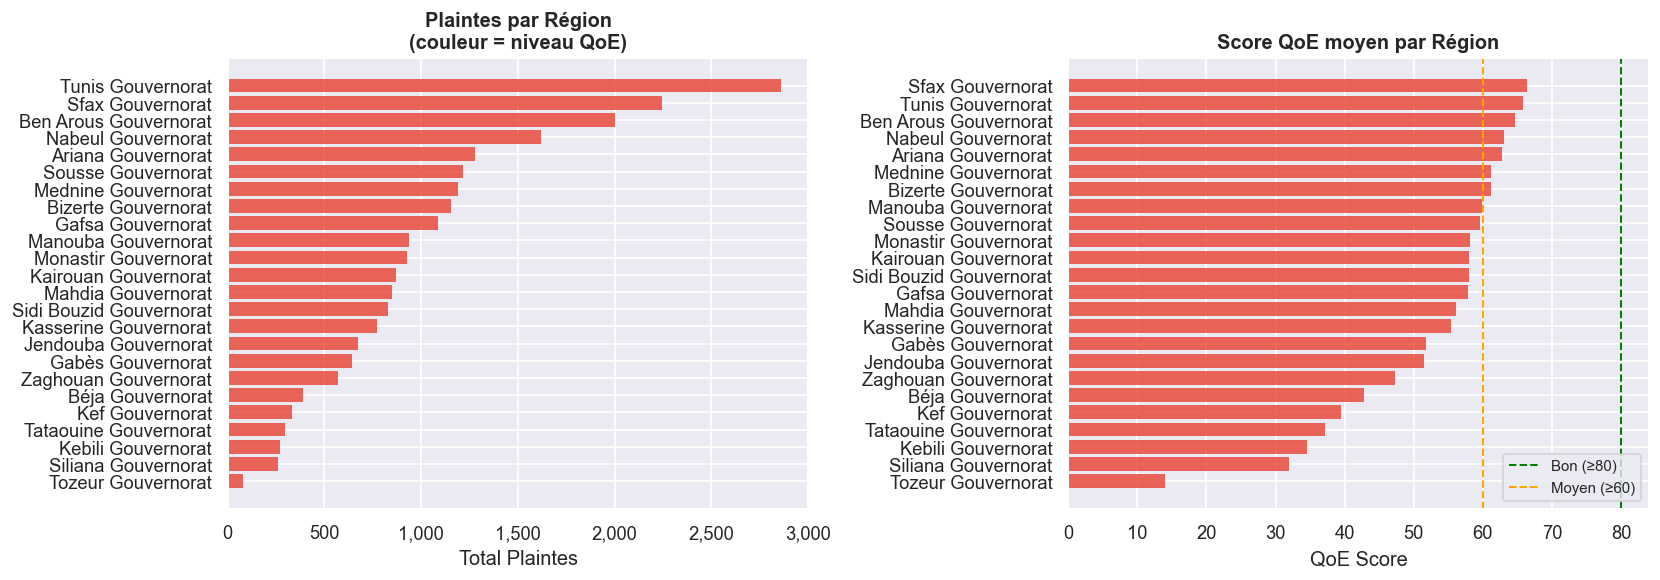

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_sorted = regional.sort_values("total_complaints")
qoe_vals   = reg_sorted["avg_qoe_score"].fillna(75)
bar_colors = [
    "#e74c3c" if q < 75 else "#f39c12" if q < 82 else "#2ecc71"
    for q in qoe_vals
]

axes[0].barh(reg_sorted["region"], reg_sorted["total_complaints"],
             color=bar_colors, edgecolor="none", alpha=0.85)
axes[0].set_title("Plaintes par Région\n(couleur = niveau QoE)", fontweight="bold")
axes[0].set_xlabel("Total Plaintes")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

if "avg_qoe_score" in regional.columns:
    reg_qoe    = regional.dropna(subset=["avg_qoe_score"]).sort_values("avg_qoe_score")
    qoe_colors = [
        "#e74c3c" if q < 75 else "#f39c12" if q < 82 else "#2ecc71"
        for q in reg_qoe["avg_qoe_score"]
    ]
    axes[1].barh(reg_qoe["region"], reg_qoe["avg_qoe_score"],
                 color=qoe_colors, edgecolor="none", alpha=0.85)
    axes[1].axvline(80, color="green",  linestyle="--", lw=1.2, label="Bon (≥80)")
    axes[1].axvline(60, color="orange", linestyle="--", lw=1.2, label="Moyen (≥60)")
    axes[1].set_title("Score QoE moyen par Région", fontweight="bold")
    axes[1].set_xlabel("QoE Score")
    axes[1].legend(fontsize=9)
else:
    axes[1].text(0.5, 0.5, "QoE non disponible",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].axis("off")

plt.tight_layout()
plt.savefig(f"{FIGURES}/st_regional_complaints_qoe.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 5 — Bubble map (matplotlib)
FIX N5: lookup uses Title-Case keys matching the data_loader output.
FIX N8: REGION_CENTROIDS imported from spatiotemporal module — no duplication.

Région lookup debug:
  'Tunis Gouvernorat' → MISSING
  'Sfax Gouvernorat' → MISSING
  'Ben Arous Gouvernorat' → MISSING
  'Nabeul Gouvernorat' → MISSING
  'Ariana Gouvernorat' → MISSING
  'Sousse Gouvernorat' → MISSING
  'Mednine Gouvernorat' → MISSING
  'Bizerte Gouvernorat' → MISSING
  'Gafsa Gouvernorat' → MISSING
  'Manouba Gouvernorat' → MISSING
  'Monastir Gouvernorat' → MISSING
  'Kairouan Gouvernorat' → MISSING
  'Mahdia Gouvernorat' → MISSING
  'Sidi Bouzid Gouvernorat' → MISSING
  'Kasserine Gouvernorat' → MISSING
  'Jendouba Gouvernorat' → MISSING
  'Gabès Gouvernorat' → MISSING
  'Zaghouan Gouvernorat' → MISSING
  'Béja Gouvernorat' → MISSING
  'Kef Gouvernorat' → MISSING
  'Tataouine Gouvernorat' → MISSING
  'Kebili Gouvernorat' → MISSING
  'Siliana Gouvernorat' → MISSING
  'Tozeur Gouvernorat' → MISSING

  ⚠ No centroid for 'Tunis Gouvernorat' — skipped
  ⚠ No centroid for 'Sfax Gouvernorat' — skipped
  ⚠ No centroid for 'Ben Arous Gouvernorat' — skipped
  ⚠ No centroid f

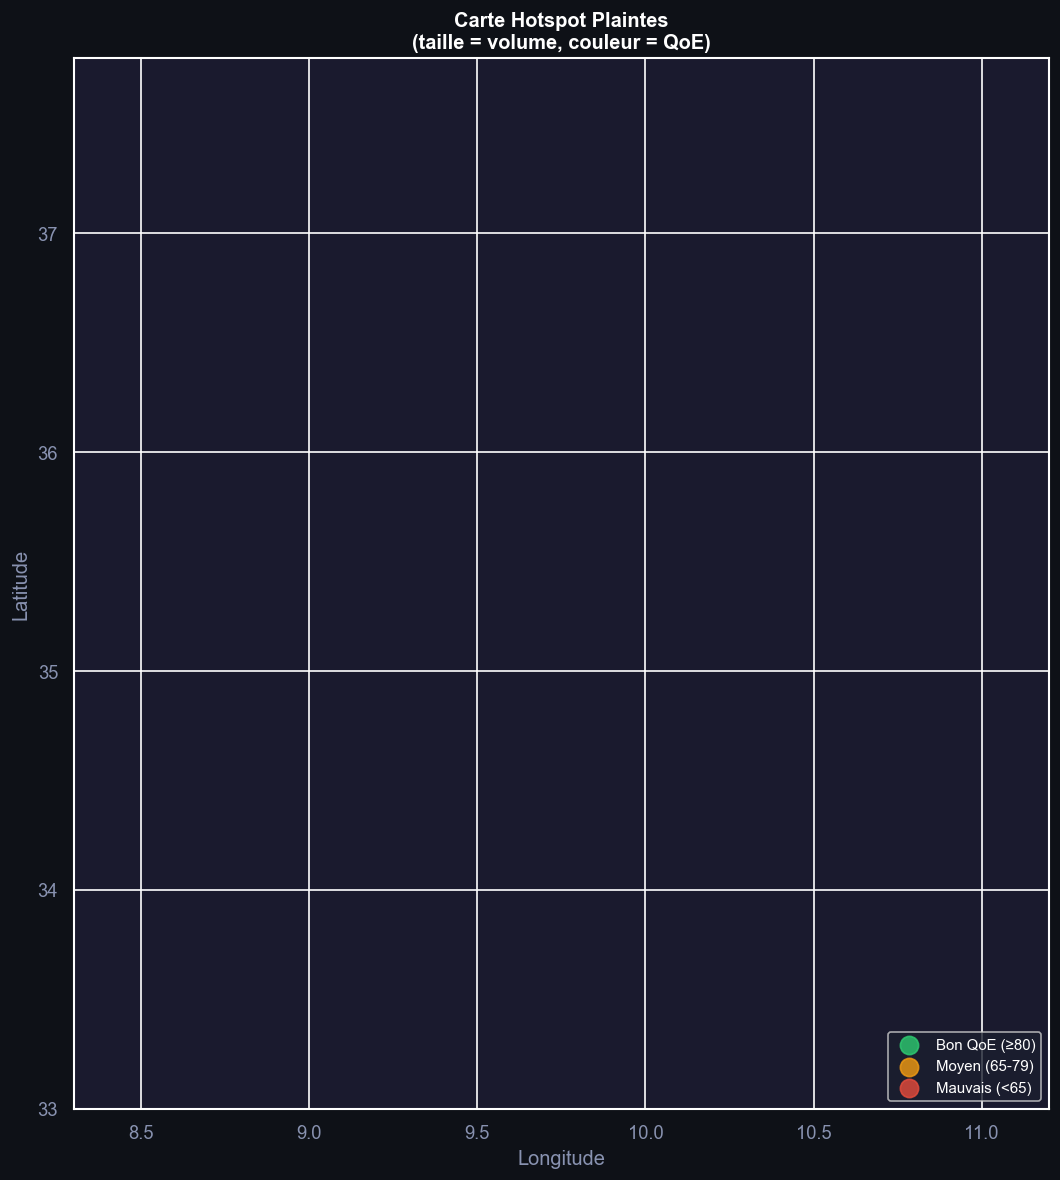

Régions affichées : 0/24


In [6]:
# Debug: show which regions resolve to coordinates
print("Région lookup debug:")
for _, row in regional.iterrows():
    region = str(row["region"]).strip()
    # Check pre-enriched lat/lon first (from data_loader or kpi join)
    lat = row.get("lat") if "lat" in regional.columns else None
    lon = row.get("lon") if "lon" in regional.columns else None
    if pd.isna(lat) or pd.isna(lon):
        coords = REGION_CENTROIDS.get(region)
        src = "module" if coords else "MISSING"
    else:
        src = "dataframe"
    print(f"  '{region}' → {src}")
print()

fig, ax = plt.subplots(figsize=(9, 10))
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#0e1117")

max_c   = regional["total_complaints"].max()
plotted = 0

for _, row in regional.iterrows():
    region = str(row["region"]).strip()

    lat = row.get("lat") if "lat" in regional.columns else None
    lon = row.get("lon") if "lon" in regional.columns else None

    if pd.isna(lat) or pd.isna(lon):
        coords = REGION_CENTROIDS.get(region)
        if coords is None:
            print(f"  ⚠ No centroid for '{region}' — skipped")
            continue
        lat, lon = coords

    count = int(row["total_complaints"])
    qoe   = row.get("avg_qoe_score", 70)
    if pd.isna(qoe):
        qoe = 70

    size  = 200 + (count / max_c) * 2000
    color = "#2ecc71" if qoe >= 80 else "#f39c12" if qoe >= 65 else "#e74c3c"

    ax.scatter(lon, lat, s=size, color=color,
               alpha=0.7, edgecolors="white", linewidths=0.8, zorder=5)
    ax.annotate(
        f"{region}\n{count:,}", (lon, lat),
        textcoords="offset points", xytext=(8, 4),
        color="white", fontsize=8, fontweight="bold", zorder=6,
    )
    plotted += 1

ax.set_xlim(8.3, 11.2)
ax.set_ylim(33.0, 37.8)
ax.set_title(
    "Carte Hotspot Plaintes\n(taille = volume, couleur = QoE)",
    color="white", fontweight="bold", fontsize=12,
)
ax.set_xlabel("Longitude", color="#8892b0")
ax.set_ylabel("Latitude",  color="#8892b0")
ax.tick_params(colors="#8892b0")
for label, color in [
    ("Bon QoE (≥80)",  "#2ecc71"),
    ("Moyen (65-79)",  "#f39c12"),
    ("Mauvais (<65)",  "#e74c3c"),
]:
    ax.scatter([], [], c=color, s=120, label=label, alpha=0.8)
ax.legend(loc="lower right", facecolor="#1a1f2e", labelcolor="white", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURES}/st_bubble_map.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Régions affichées : {plotted}/{len(regional)}")

## Cell 6 — Temporal patterns

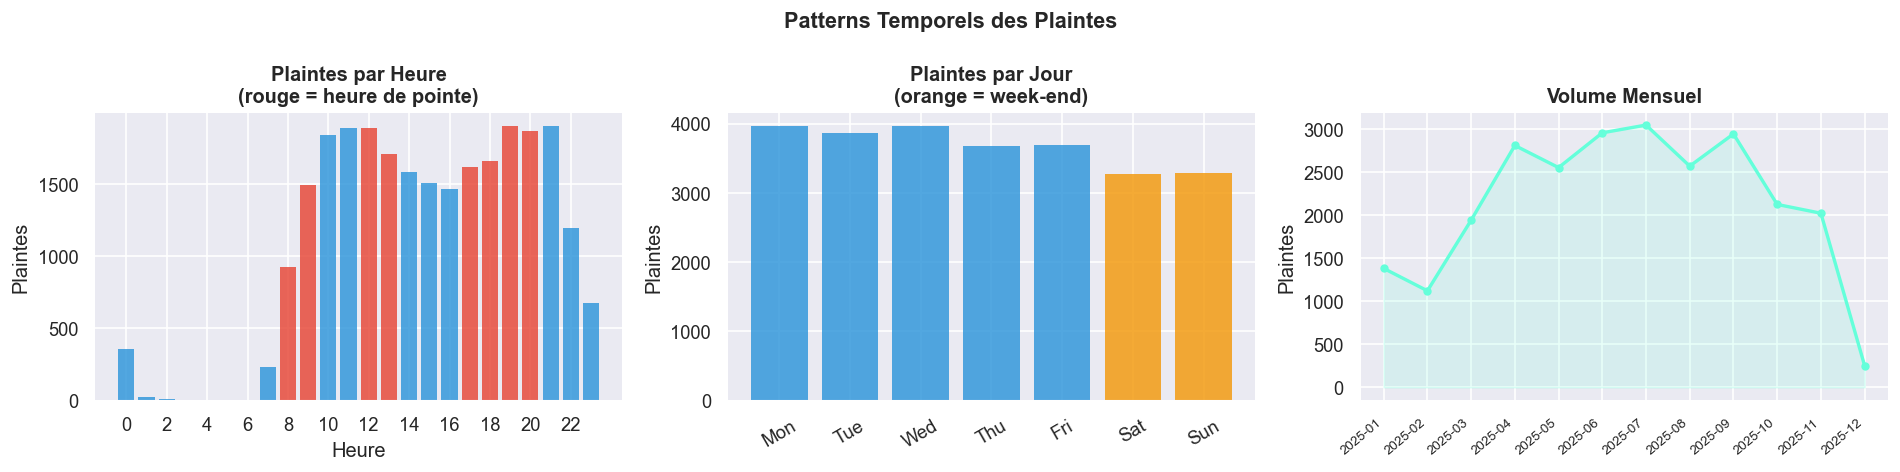

Heure de pointe : 19h00  |  Ratio peak/off-peak : 1.03x


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Hourly
bar_c = [
    "#e74c3c" if row["is_peak"] else "#3498db"
    for _, row in hourly.iterrows()
]
axes[0].bar(hourly["hour"], hourly["complaint_count"],
            color=bar_c, edgecolor="none", alpha=0.85)
axes[0].set_title("Plaintes par Heure\n(rouge = heure de pointe)", fontweight="bold")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Plaintes")
axes[0].set_xticks(range(0, 24, 2))

# Day of week
dow_c = ["#f39c12" if w else "#3498db" for w in dow["is_weekend"]]
axes[1].bar(range(len(dow)), dow["complaint_count"],
            color=dow_c, edgecolor="none", alpha=0.85)
axes[1].set_xticks(range(len(dow)))
axes[1].set_xticklabels(
    [str(d)[:3] for d in dow["day_of_week"]], rotation=30
)
axes[1].set_title("Plaintes par Jour\n(orange = week-end)", fontweight="bold")
axes[1].set_ylabel("Plaintes")

# Monthly trend
if "total" in monthly.columns and len(monthly) > 0:
    axes[2].plot(range(len(monthly)), monthly["total"],
                 marker="o", markersize=4, color="#64ffda", linewidth=2)
    axes[2].fill_between(range(len(monthly)), monthly["total"],
                         alpha=0.15, color="#64ffda")
    tick_step = max(1, len(monthly) // 8)
    axes[2].set_xticks(range(0, len(monthly), tick_step))
    axes[2].set_xticklabels(
        monthly["month_label"].iloc[::tick_step],
        rotation=40, ha="right", fontsize=8,
    )
    axes[2].set_title("Volume Mensuel", fontweight="bold")
    axes[2].set_ylabel("Plaintes")
else:
    axes[2].text(0.5, 0.5, "Données mensuelles non disponibles",
                 ha="center", va="center", transform=axes[2].transAxes)

plt.suptitle("Patterns Temporels des Plaintes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES}/st_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

peak_h = int(hourly.loc[hourly["complaint_count"].idxmax(), "hour"])
ratio  = results["summary"].get("peak_offpeak_ratio", 0)
print(f"Heure de pointe : {peak_h:02d}h00  |  Ratio peak/off-peak : {ratio:.2f}x")

## Cell 7 — Monthly stacked bar by service type

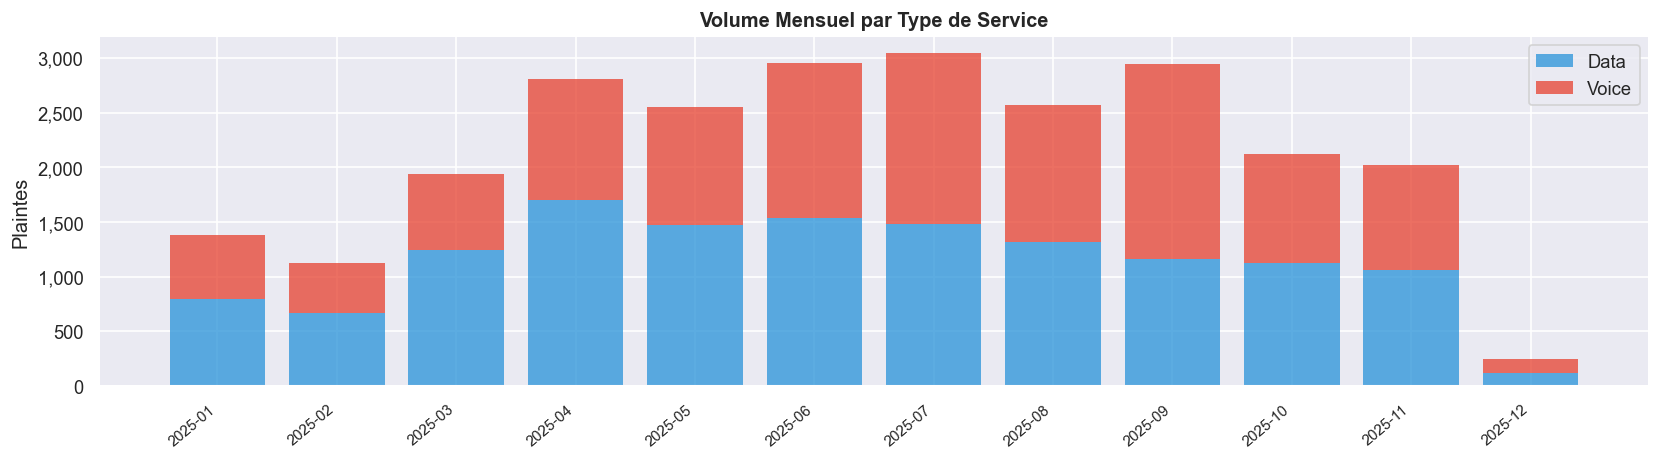

In [8]:
svc_cols_m = [
    c for c in monthly.columns if c not in ("month_label", "total")
]

if svc_cols_m and len(monthly) > 0:
    fig, ax = plt.subplots(figsize=(14, 4))
    x       = range(len(monthly))
    bottom  = np.zeros(len(monthly))
    palette = {
        "Data": "#3498db", "Voice": "#e74c3c",
        "Unknown": "#95a5a6", "SMS": "#2ecc71",
    }
    for col in sorted(svc_cols_m):
        color = palette.get(col, "#9b59b6")
        ax.bar(x, monthly[col], bottom=bottom, label=col,
               color=color, alpha=0.8, edgecolor="none")
        bottom += monthly[col].values

    tick_step = max(1, len(monthly) // 8)
    ax.set_xticks(range(0, len(monthly), tick_step))
    ax.set_xticklabels(
        monthly["month_label"].iloc[::tick_step],
        rotation=40, ha="right", fontsize=9,
    )
    ax.set_title("Volume Mensuel par Type de Service", fontweight="bold")
    ax.set_ylabel("Plaintes")
    ax.legend(loc="upper right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/st_monthly_service_stacked.png",
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Pas de colonnes de service type dans monthly — graphique skippé.")

## Cell 8 — Hour × Day-of-Week heatmap (global)
FIX N2: safe axvline using np.searchsorted instead of list.index()
which raises ValueError when the hour is not in the column index.

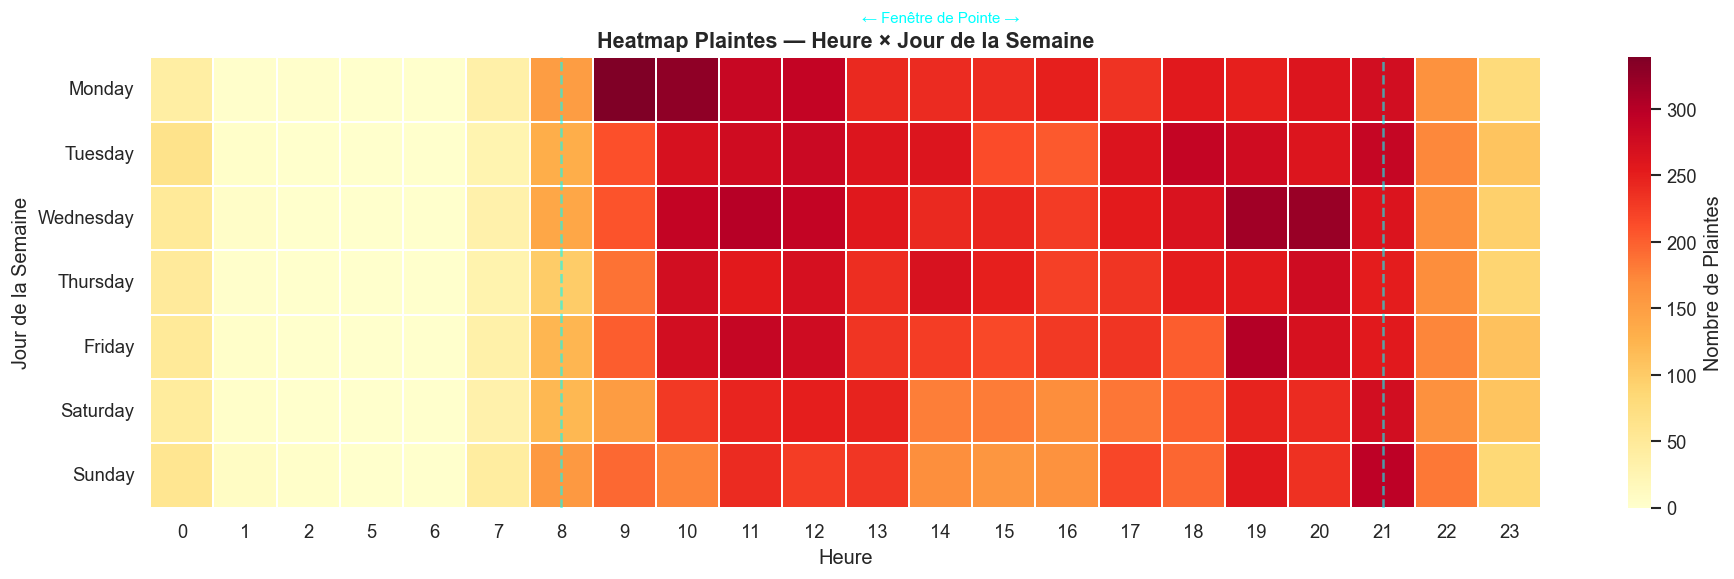

In [9]:
cols = list(hour_dow.columns)   # integer hours

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(hour_dow, cmap="YlOrRd", linewidths=0.2, ax=ax,
            cbar_kws={"label": "Nombre de Plaintes"})
ax.set_title(
    "Heatmap Plaintes — Heure × Jour de la Semaine",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("Heure")
ax.set_ylabel("Jour de la Semaine")

# FIX N2: safe peak-window markers — hours 8 and 21 may not be in cols
for marker_hour, label_x_offset in [(8, 0.5), (21, 0.5)]:
    if marker_hour in cols:
        xpos = cols.index(marker_hour)
        ax.axvline(x=xpos + 0.5, color="cyan", linewidth=1.5,
                   linestyle="--", alpha=0.6)
    # Silently skip if hour not present — no ValueError

# Label the peak window if both boundaries exist
h8_in  = 8  in cols
h21_in = 21 in cols
if h8_in and h21_in:
    mid_x = (cols.index(8) + cols.index(21)) / 2
    ax.text(mid_x, -0.5, "← Fenêtre de Pointe →",
            color="cyan", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES}/st_hour_dow_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 9 — Hour × Day heatmap per top-4 regions
FIX N3: always derive hour/day_of_week from timestamp to ensure
consistency regardless of what columns previous notebooks added.

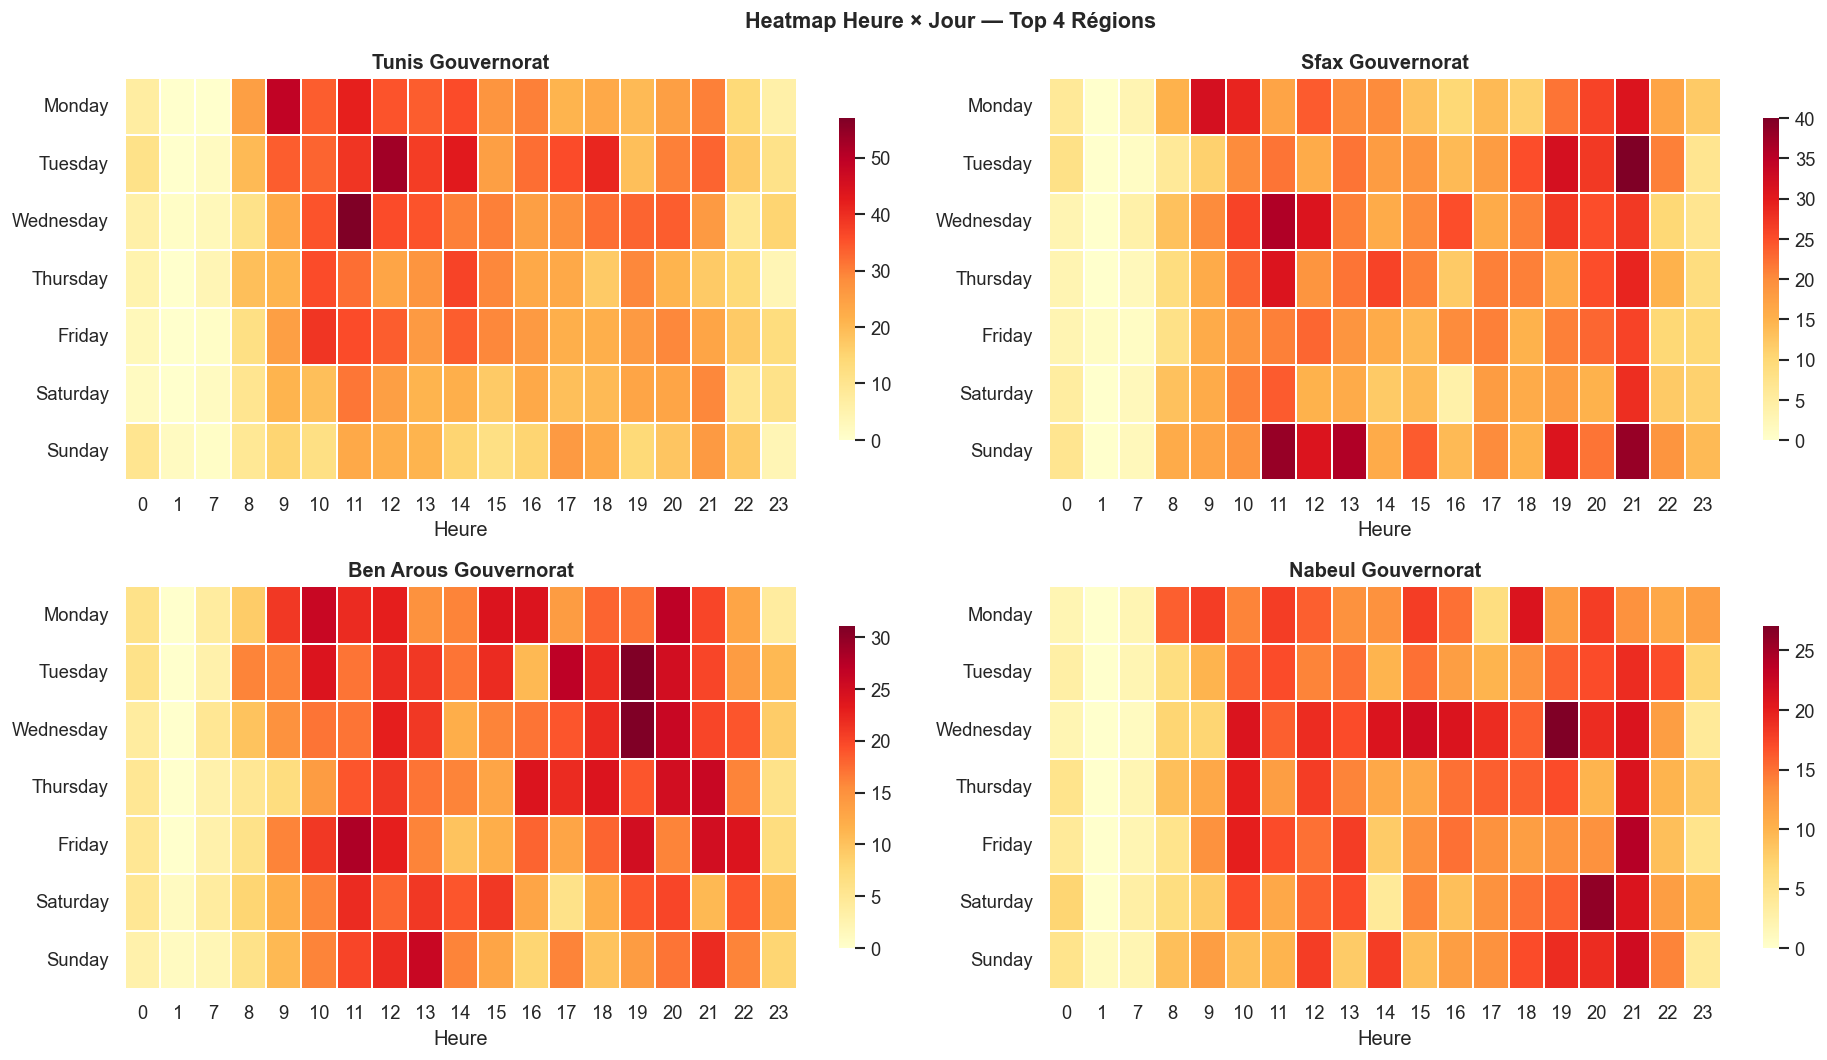

In [10]:
top4 = results["regional_hotspots"]["region"].head(4).tolist()
DOW  = ["Monday", "Tuesday", "Wednesday", "Thursday",
        "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for i, region in enumerate(top4):
    reg_df = complaints_clean[complaints_clean["region"] == region].copy()
    # FIX N3: always derive from timestamp for consistency
    reg_df["_hour"] = reg_df["timestamp"].dt.hour
    reg_df["_dow"]  = reg_df["timestamp"].dt.day_name()

    present_days = [d for d in DOW if d in reg_df["_dow"].unique()]
    pivot = (
        reg_df.groupby(["_dow", "_hour"])
        .size()
        .unstack(fill_value=0)
        .reindex(present_days)
    )
    sns.heatmap(pivot, cmap="YlOrRd", ax=axes[i],
                linewidths=0.2, cbar=True, cbar_kws={"shrink": 0.8})
    axes[i].set_title(region, fontweight="bold")
    axes[i].set_xlabel("Heure")
    axes[i].set_ylabel("")

plt.suptitle("Heatmap Heure × Jour — Top 4 Régions",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES}/st_hour_dow_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 10 — Anomaly burst table

In [11]:
if bursts.empty:
    print("Aucun burst détecté.")
else:
    n_critical = (bursts["severity"] == "Critical").sum()
    n_high     = (bursts["severity"] == "High").sum()
    print(f"Total : {len(bursts)}  |  Critiques : {n_critical}  |  Haut : {n_high}")
    display(  # type: ignore[name-defined]
        bursts[[
            "region", "burst_start", "burst_end", "duration_days",
            "total_complaints", "peak_zscore", "severity",
        ]].head(15)
    )

Total : 253  |  Critiques : 90  |  Haut : 163


,region,burst_start,burst_end,duration_days,total_complaints,peak_zscore,severity
0,Sfax Gouvernorat,2025-06-08,2025-06-08,1,120,15.68,Critical
1,Béja Gouvernorat,2025-04-19,2025-04-19,1,32,15.21,Critical
2,Jendouba Gouvernorat,2025-02-17,2025-02-17,1,60,14.58,Critical
3,Bizerte Gouvernorat,2025-12-01,2025-12-01,1,37,10.94,Critical
4,Zaghouan Gouvernorat,2025-07-11,2025-07-11,1,20,8.02,Critical
5,Manouba Gouvernorat,2025-06-19,2025-06-25,7,87,7.54,Critical
6,Kebili Gouvernorat,2025-09-14,2025-09-14,1,9,7.07,Critical
7,Ben Arous Gouvernorat,2025-06-23,2025-06-25,3,76,6.69,Critical
8,Kebili Gouvernorat,2025-05-20,2025-05-20,1,8,6.21,Critical
9,Kebili Gouvernorat,2025-04-16,2025-04-17,2,12,6.21,Critical


## Cell 11 — Burst time-series — top 4 regions
FIX N4: use pd.to_datetime() instead of pd.Timestamp() for axvspan dates.

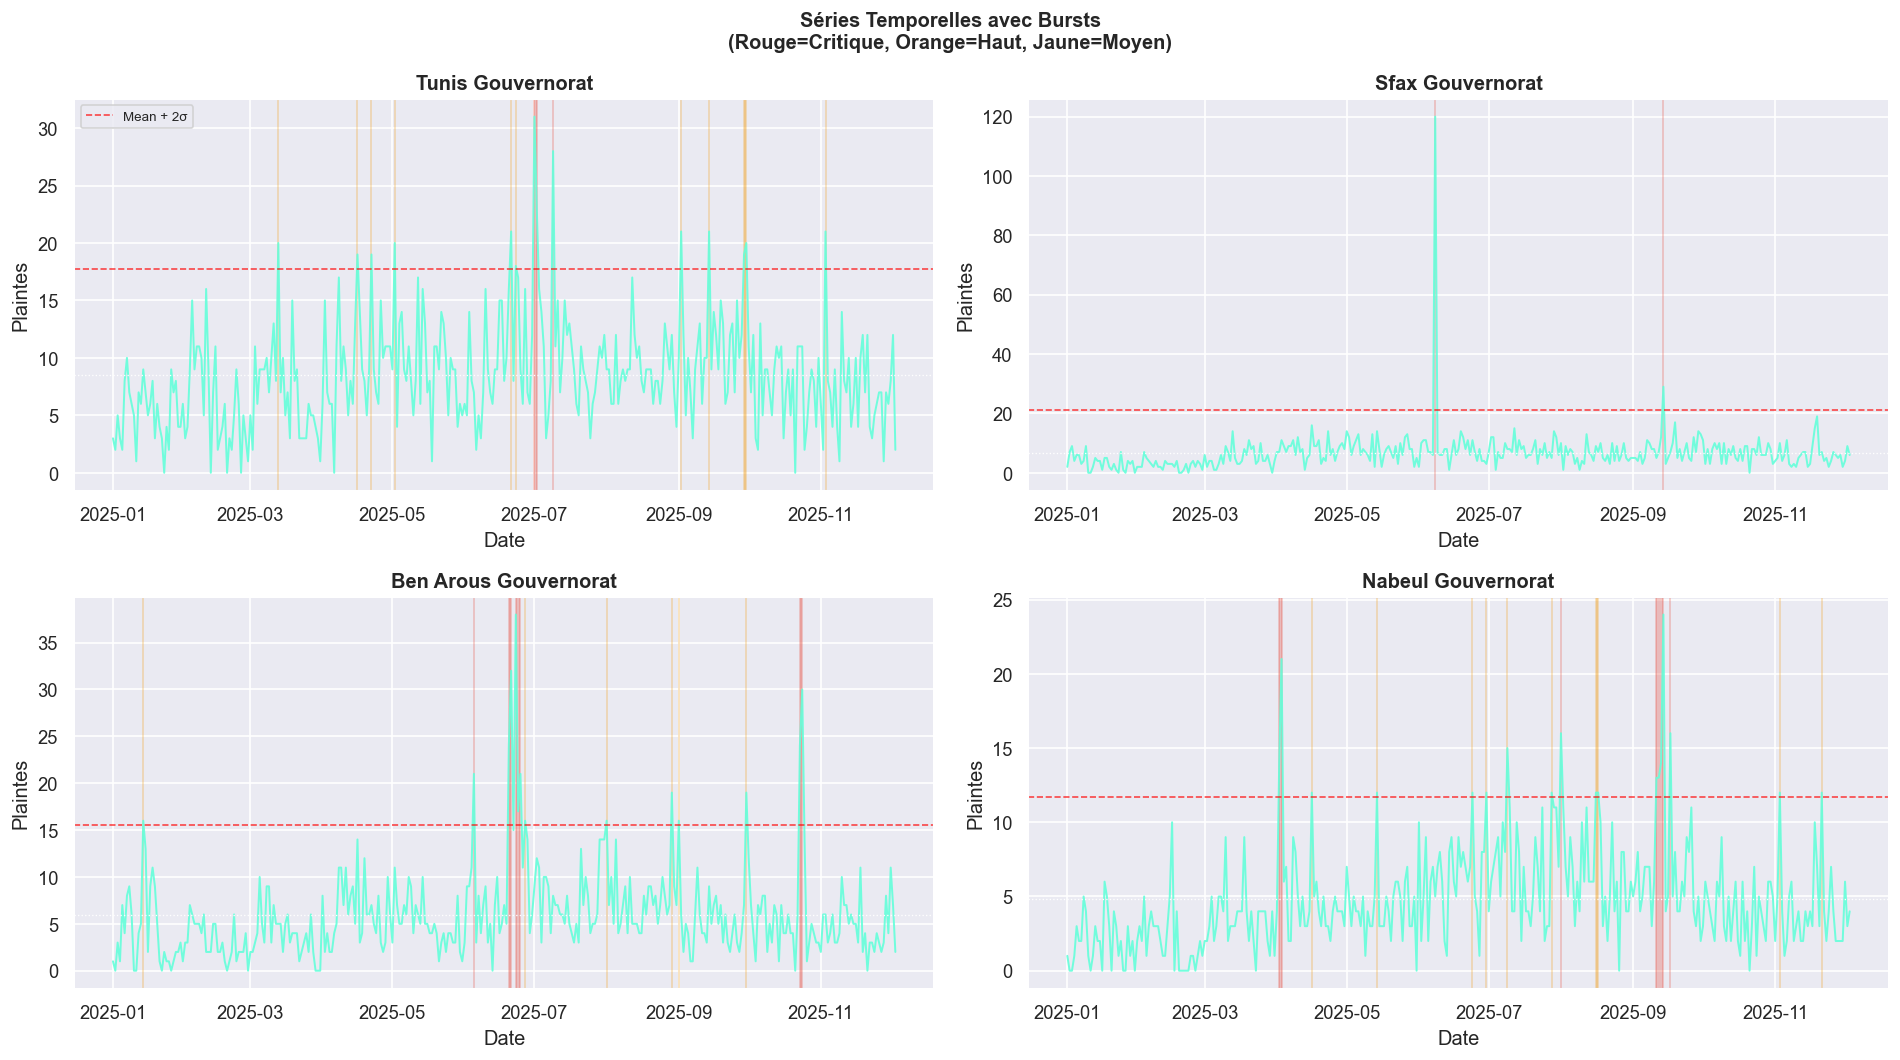

In [12]:
top4 = results["regional_hotspots"]["region"].head(4).tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for i, region in enumerate(top4):
    ca_r = complaint_agg[complaint_agg["region"] == region].sort_values("date")
    br   = bursts[bursts["region"] == region] if not bursts.empty else pd.DataFrame()

    axes[i].plot(ca_r["date"], ca_r["total_complaints"],
                 color="#64ffda", linewidth=1.2, alpha=0.9)

    if not br.empty:
        for _, burst in br.iterrows():
            color = (
                "#e74c3c" if burst["severity"] == "Critical" else
                "#f39c12" if burst["severity"] == "High" else
                "#f1c40f"
            )
            # FIX N4: pd.to_datetime() safe for both date and Timestamp objects
            axes[i].axvspan(
                pd.to_datetime(burst["burst_start"]),
                pd.to_datetime(burst["burst_end"]),
                alpha=0.3, color=color,
            )

    m = ca_r["total_complaints"].mean()
    s = ca_r["total_complaints"].std()
    axes[i].axhline(m + 2 * s, color="red", linestyle="--",
                    linewidth=1, alpha=0.7, label="Mean + 2σ")
    axes[i].axhline(m, color="white", linestyle=":", linewidth=0.8)
    axes[i].set_title(region, fontweight="bold")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Plaintes")
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle(
    "Séries Temporelles avec Bursts\n"
    "(Rouge=Critique, Orange=Haut, Jaune=Moyen)",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig(f"{FIGURES}/st_burst_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 12 — Burst severity & region breakdown

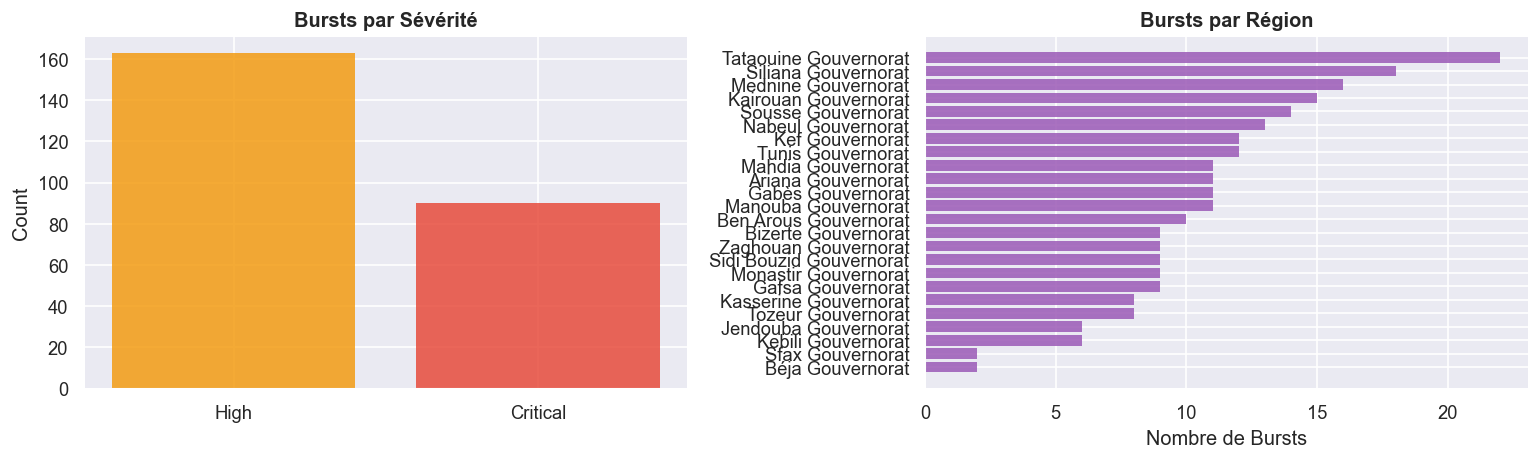

In [13]:
if not bursts.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sev    = bursts["severity"].value_counts()
    colors = [
        "#e74c3c" if s == "Critical" else
        "#f39c12" if s == "High" else
        "#f1c40f"
        for s in sev.index
    ]
    axes[0].bar(sev.index, sev.values, color=colors, alpha=0.85, edgecolor="none")
    axes[0].set_title("Bursts par Sévérité", fontweight="bold")
    axes[0].set_ylabel("Count")

    bpr = bursts.groupby("region").size().sort_values()
    axes[1].barh(bpr.index, bpr.values, color="#9b59b6", alpha=0.85, edgecolor="none")
    axes[1].set_title("Bursts par Région", fontweight="bold")
    axes[1].set_xlabel("Nombre de Bursts")

    plt.tight_layout()
    plt.savefig(f"{FIGURES}/st_burst_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Pas de bursts détectés — graphique skippé.")

## Cell 13 — Service-type by region

service_type,region,Data,Voice,Data_pct,Voice_pct,dominant_service
0,Ariana Gouvernorat,665,614,52.0,48.0,Data
1,Ben Arous Gouvernorat,1087,917,54.2,45.8,Data
2,Bizerte Gouvernorat,631,524,54.6,45.4,Data
3,Béja Gouvernorat,220,169,56.6,43.4,Data
4,Gabès Gouvernorat,399,242,62.2,37.8,Data
5,Gafsa Gouvernorat,598,491,54.9,45.1,Data
6,Jendouba Gouvernorat,397,279,58.7,41.3,Data
7,Kairouan Gouvernorat,500,368,57.6,42.4,Data
8,Kasserine Gouvernorat,449,322,58.2,41.8,Data
9,Kebili Gouvernorat,152,118,56.3,43.7,Data


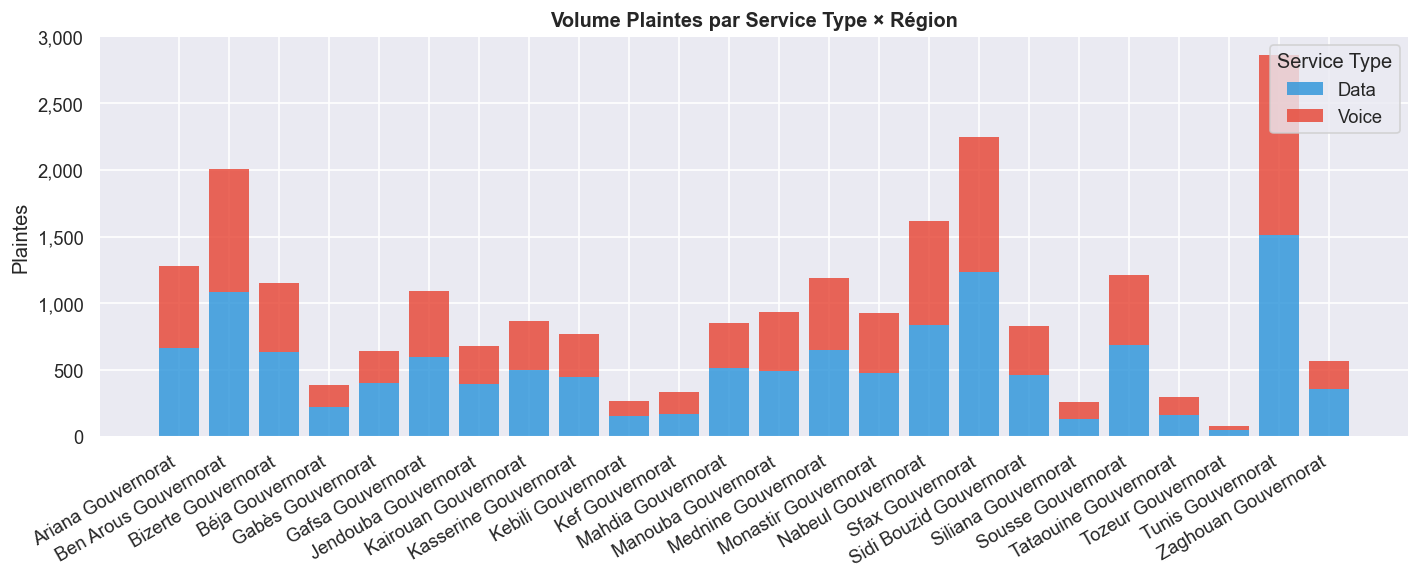

In [14]:
display(svc)  # type: ignore[name-defined]

svc_cols = [
    c for c in svc.columns
    if c not in ("region", "dominant_service") and not c.endswith("_pct")
]
palette = {
    "Data": "#3498db", "Voice": "#e74c3c",
    "Unknown": "#95a5a6", "SMS": "#2ecc71",
}

if svc_cols:
    fig, ax = plt.subplots(figsize=(12, 5))
    x       = np.arange(len(svc))
    bottom  = np.zeros(len(svc))
    for col in sorted(svc_cols):
        color = palette.get(col, "#9b59b6")
        ax.bar(x, svc[col], bottom=bottom, label=col,
               color=color, alpha=0.85, edgecolor="none")
        bottom += svc[col].values

    ax.set_xticks(x)
    ax.set_xticklabels(svc["region"], rotation=30, ha="right")
    ax.set_title("Volume Plaintes par Service Type × Région", fontweight="bold")
    ax.set_ylabel("Plaintes")
    ax.legend(title="Service Type", loc="upper right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/st_service_by_region.png", dpi=150, bbox_inches="tight")
    plt.show()

## Cell 14 — Category × region heatmap
FIX N7: guard against empty cat_cols list.

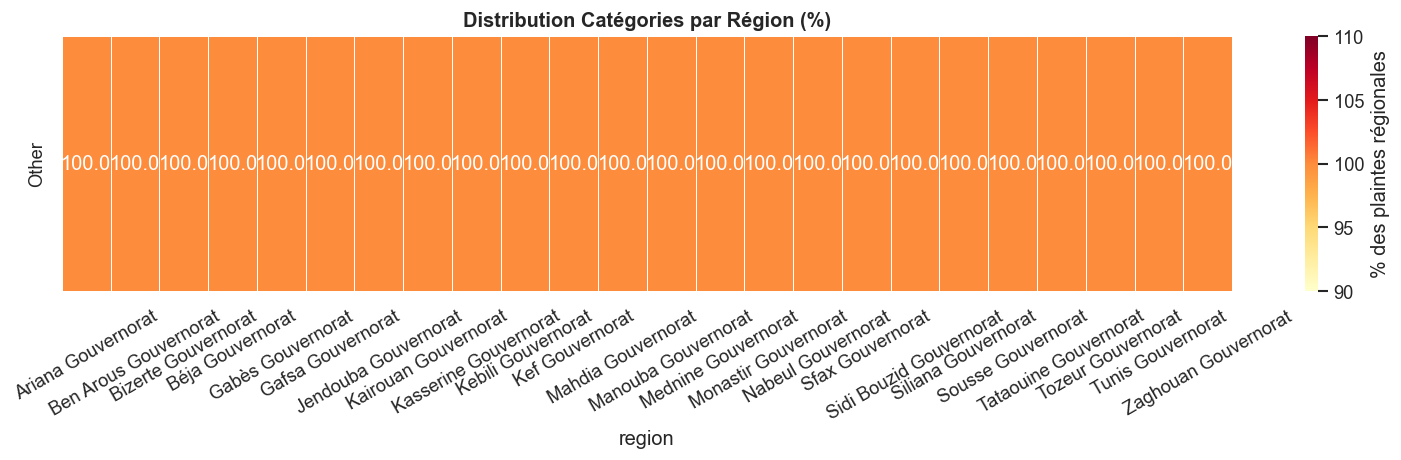

In [15]:
cat_cols = [c for c in complaint_agg.columns if c.startswith("cat_")]

if not cat_cols:
    print("Pas de colonnes cat_* dans complaint_agg — heatmap catégorie skippée.")
    print("(Cela arrive si complaint_category n'avait pas de valeurs lors du pivot.)")
else:
    cat_pivot = complaint_agg.groupby("region")[cat_cols].sum()
    cat_pivot.columns = [
        c.replace("cat_", "").replace("_", " ").title() for c in cat_pivot.columns
    ]
    row_totals = cat_pivot.sum(axis=1).replace(0, np.nan)
    cat_norm   = cat_pivot.div(row_totals, axis=0).mul(100).fillna(0)

    fig, ax = plt.subplots(figsize=(13, max(4, len(cat_norm.columns) * 0.5)))
    sns.heatmap(cat_norm.T, annot=True, fmt=".1f", cmap="YlOrRd",
                linewidths=0.3, ax=ax,
                cbar_kws={"label": "% des plaintes régionales"})
    ax.set_title("Distribution Catégories par Région (%)",
                 fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/st_category_by_region_heatmap.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## Cell 15 — Cell-level hotspot analysis

=== Analyse Cell-Level ===
  Pas de colonne cell_id dans les données DCLM réelles.
  → Section skippée. Analyse disponible au niveau région uniquement.

  → Alternatif : Top 15 sous-catégories de plaintes


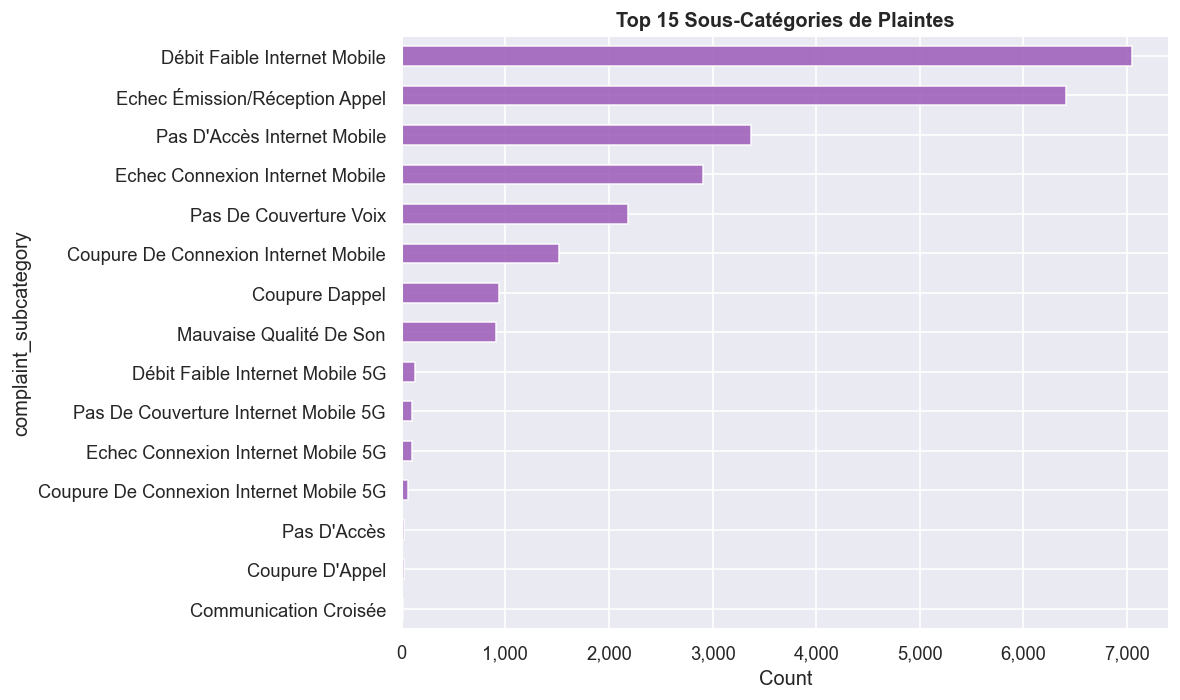

In [16]:
print("=== Analyse Cell-Level ===")
if cells.empty:
    print("  Pas de colonne cell_id dans les données DCLM réelles.")
    print("  → Section skippée. Analyse disponible au niveau région uniquement.")
    print()
    # Alternative: top-15 sub-categories
    print("  → Alternatif : Top 15 sous-catégories de plaintes")
    if "complaint_subcategory" in complaints_clean.columns:
        top15_sub = (
            complaints_clean["complaint_subcategory"]
            .value_counts()
            .drop("Unknown", errors="ignore")
            .head(15)
        )
        if not top15_sub.empty:
            fig, ax = plt.subplots(figsize=(10, 6))
            top15_sub.sort_values().plot(kind="barh", ax=ax,
                                         color="#9b59b6", alpha=0.85)
            ax.set_title("Top 15 Sous-Catégories de Plaintes", fontweight="bold")
            ax.set_xlabel("Count")
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
            )
            plt.tight_layout()
            plt.savefig(f"{FIGURES}/st_subcategory_top15.png",
                        dpi=150, bbox_inches="tight")
            plt.show()
        else:
            print("  Pas de sous-catégories disponibles.")
    else:
        print("  Colonne complaint_subcategory absente.")
else:
    display(  # type: ignore[name-defined]
        cells[[
            "cell_rank", "cell_id", "region",
            "total_complaints", "dominant_category",
        ]].to_string(index=False)
    )

    top15 = cells.head(15).sort_values("total_complaints")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        top15["cell_id"] + " (" + top15["region"] + ")",
        top15["total_complaints"],
        color=COLORS[: len(top15)], edgecolor="none", alpha=0.85,
    )
    ax.set_title("Top 15 Cellules par Volume de Plaintes", fontweight="bold")
    ax.set_xlabel("Total Plaintes")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/st_cell_hotspots.png", dpi=150, bbox_inches="tight")
    plt.show()

## Cell 16 — Weekly trend: top regions (or cells if available)

→ Tendance hebdomadaire — Top 3 régions


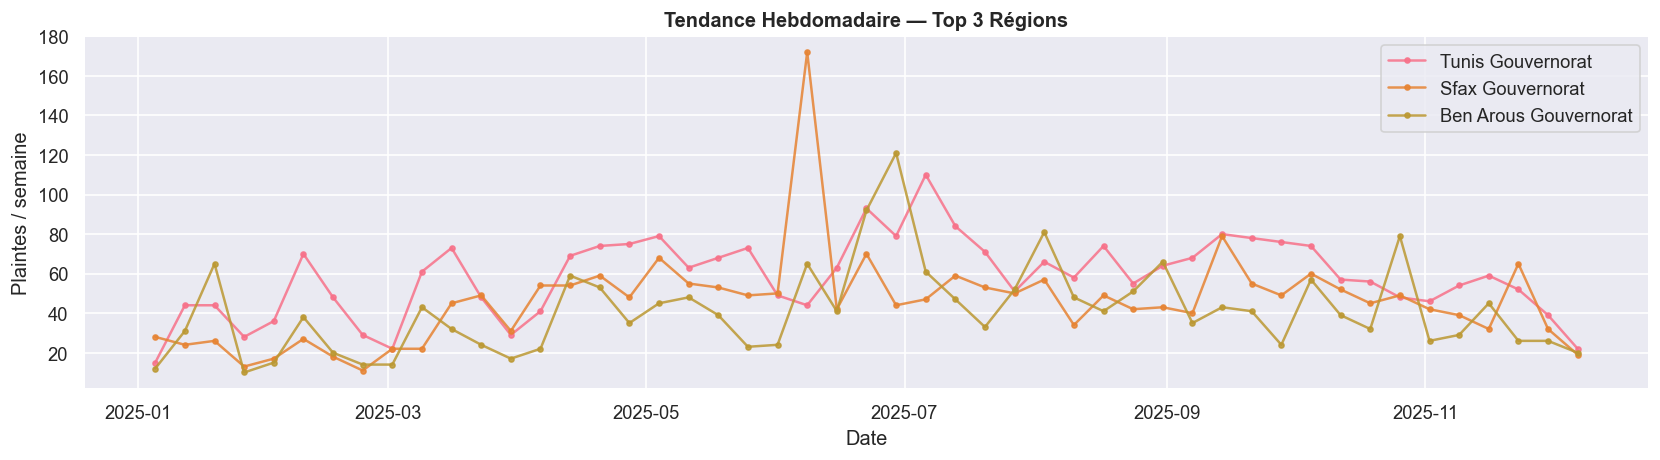

In [17]:
if cells.empty or "cell_id" not in complaints_clean.columns:
    print("→ Tendance hebdomadaire — Top 3 régions")
    top3_regions = results["regional_hotspots"]["region"].head(3).tolist()

    fig, ax = plt.subplots(figsize=(14, 4))
    for i, region in enumerate(top3_regions):
        reg_ts = (
            complaint_agg[complaint_agg["region"] == region]
            .sort_values("date")
            .set_index("date")["total_complaints"]
            .resample("W")
            .sum()
            .reset_index()
        )
        ax.plot(reg_ts["date"], reg_ts["total_complaints"],
                linewidth=1.5, marker="o", markersize=3,
                color=COLORS[i], label=region, alpha=0.85)

    ax.set_title("Tendance Hebdomadaire — Top 3 Régions", fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Plaintes / semaine")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/st_region_trend.png", dpi=150, bbox_inches="tight")
    plt.show()

else:
    print("→ Tendance hebdomadaire — Top 3 cellules")
    top3_cells = cells.head(3)["cell_id"].tolist()
    cell_trend = (
        complaints_clean[complaints_clean["cell_id"].isin(top3_cells)]
        .assign(date=lambda d: pd.to_datetime(d["timestamp"].dt.date))
        .groupby(["date", "cell_id"])
        .size()
        .reset_index(name="count")
    )
    cell_trend_w = (
        cell_trend.set_index("date")
        .groupby("cell_id")["count"]
        .resample("W")
        .sum()
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(14, 4))
    for i, cell in enumerate(top3_cells):
        ct = cell_trend_w[cell_trend_w["cell_id"] == cell]
        ax.plot(ct["date"], ct["count"], linewidth=1.5,
                marker="o", markersize=3, color=COLORS[i],
                label=cell, alpha=0.85)
    ax.set_title("Tendance Hebdomadaire — Top 3 Cellules", fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Plaintes / semaine")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/st_cell_trend.png", dpi=150, bbox_inches="tight")
    plt.show()

## Cell 17 — Deliverable D3 Summary

In [18]:
summary = results["summary"]
print("=" * 60)
print("  DELIVERABLE D3 (Part 1) — KEY FINDINGS")
print("=" * 60)
if "top_hotspot_region" in summary:
    print(f"  Top hotspot    : {summary['top_hotspot_region']} "
          f"({summary['top_hotspot_complaints']:,} complaints)")
    print(f"  Dominant issue : {summary['top_hotspot_category']}")
if "peak_hour" in summary:
    print(f"  Peak hour      : {summary['peak_hour']:02d}:00 "
          f"({summary['peak_hour_label']})")
    print(f"  Peak/off-peak  : {summary['peak_offpeak_ratio']:.2f}x")
if "total_burst_events" in summary:
    print(f"  Burst events   : {summary['total_burst_events']} total "
          f"| {summary['critical_bursts']} critical")
    print(f"  Most bursty    : {summary['most_bursty_region']}")
print()
print("  Outputs saved:")
for fname in [
    "st_regional_complaints_qoe.png", "st_bubble_map.png",
    "st_temporal_patterns.png",       "st_monthly_service_stacked.png",
    "st_hour_dow_heatmap.png",        "st_hour_dow_by_region.png",
    "st_burst_timeseries.png",        "st_burst_analysis.png",
    "st_service_by_region.png",       "st_category_by_region_heatmap.png",
]:
    exists = Path(f"{FIGURES}/{fname}").exists()
    print(f"  {'✓' if exists else '✗'} {fname}")

print()
folium_path = Path("reports/exports/st_regional_map.html")
print(f"  {'✓' if folium_path.exists() else '✗'} Folium map: {folium_path}")
print("=" * 60)
print("  → Next: Notebook 04 — Correlation & Root Cause Analysis")

  DELIVERABLE D3 (Part 1) — KEY FINDINGS
  Top hotspot    : Tunis Gouvernorat (2,859 complaints)
  Dominant issue : Other
  Peak hour      : 19:00 (Evening (17-20))
  Peak/off-peak  : 1.03x
  Burst events   : 253 total | 90 critical
  Most bursty    : Tataouine Gouvernorat

  Outputs saved:
  ✓ st_regional_complaints_qoe.png
  ✓ st_bubble_map.png
  ✓ st_temporal_patterns.png
  ✓ st_monthly_service_stacked.png
  ✓ st_hour_dow_heatmap.png
  ✓ st_hour_dow_by_region.png
  ✓ st_burst_timeseries.png
  ✓ st_burst_analysis.png
  ✓ st_service_by_region.png
  ✓ st_category_by_region_heatmap.png

  ✓ Folium map: reports\exports\st_regional_map.html
  → Next: Notebook 04 — Correlation & Root Cause Analysis
